In [1]:
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.preprocessing import StandardScaler
import umap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

C:\Users\Niels de Klerk\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [198]:
df_total = pd.read_pickle('../../all_fluxes_new.pkl')

In [133]:
df_total.columns

Index(['id', 'tile_index', 'ra', 'dec', 'FWHM', 'point_source_probability_mer',
       'weight_size', 'CFIS-U', 'CFIS-U_sigma', 'NIR-Y', 'NIR-Y_sigma',
       'CFIS-R', 'CFIS-R_sigma', 'NIR-J', 'NIR-J_sigma', 'NIR-H',
       'NIR-H_sigma', 'WISHES-Z', 'WISHES-Z_sigma', 'PANSTARRS-I',
       'PANSTARRS-I_sigma', 'WISHES-G', 'WISHES-G_sigma', 'VIS', 'VIS_sigma',
       'DES-Z', 'DES-Z_sigma', 'DES-I', 'DES-I_sigma', 'DES-G', 'DES-G_sigma',
       'DES-R', 'DES-R_sigma', 'label'],
      dtype='str')

In [134]:
DES = False

In [135]:
if DES:
    bands = ['DES-G','DES-R','DES-I','DES-Z','VIS','NIR-Y','NIR-J','NIR-H']
else:
    bands = ['CFIS-U','WISHES-G','CFIS-R','PANSTARRS-I','WISHES-Z','VIS','NIR-Y','NIR-J','NIR-H']

mask = pd.Series(True, index=df_total.index)

for b in bands:
    mask &= df_total[b] / df_total[f'{b}_sigma'] > 5
df_sel = df_total[mask].copy()

In [136]:
for b in bands:
    df_sel[f'{b}_mag'] = -2.5*np.log10(df_sel[b])

In [138]:
if DES:
    df_sel['g_r'] = df_sel['DES-G_mag'] - df_sel['DES-R_mag']
    df_sel['r_i'] = df_sel['DES-R_mag'] - df_sel['DES-I_mag']
    df_sel['i_z'] = df_sel['DES-I_mag'] - df_sel['DES-Z_mag']
    df_sel['z_VIS'] = df_sel['DES-Z_mag'] - df_sel['VIS_mag']
    df_sel['VIS_Y'] = df_sel['VIS_mag'] - df_sel['NIR-Y_mag']
    df_sel['Y_J'] = df_sel['NIR-Y_mag'] - df_sel['NIR-J_mag']
    df_sel['J_H'] = df_sel['NIR-J_mag'] - df_sel['NIR-H_mag']
    df_sel['g_H'] = df_sel['DES-G_mag'] - df_sel['NIR-H_mag']
else:
    df_sel['u_g'] = df_sel['CFIS-U_mag'] - df_sel['WISHES-G_mag']
    df_sel['g_r'] = df_sel['WISHES-G_mag'] - df_sel['CFIS-R_mag']
    df_sel['r_i'] = df_sel['CFIS-R_mag'] - df_sel['PANSTARRS-I_mag']
    df_sel['i_z'] = df_sel['PANSTARRS-I_mag'] - df_sel['WISHES-Z_mag']
    df_sel['z_VIS'] = df_sel['WISHES-Z_mag'] - df_sel['VIS_mag']
    df_sel['VIS_Y'] = df_sel['VIS_mag'] - df_sel['NIR-Y_mag']
    df_sel['Y_J'] = df_sel['NIR-Y_mag'] - df_sel['NIR-J_mag']
    df_sel['J_H'] = df_sel['NIR-J_mag'] - df_sel['NIR-H_mag']
    df_sel['u_H'] = df_sel['CFIS-U_mag'] - df_sel['NIR-H_mag']

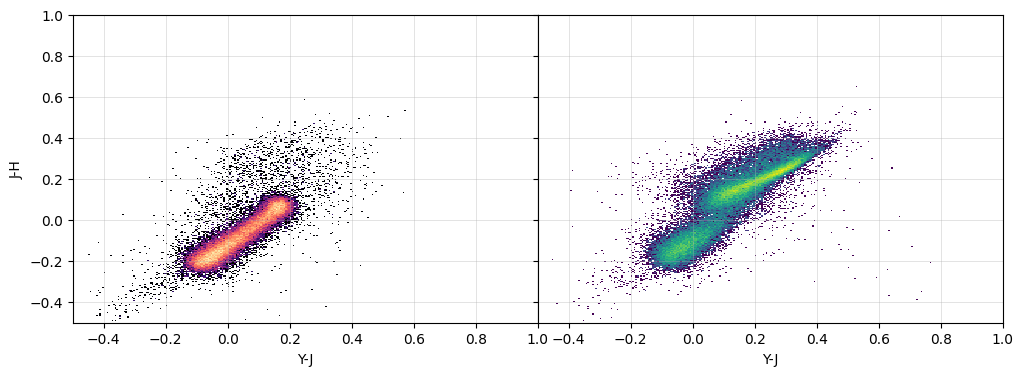

In [140]:
xmin,xmax = -.5, 1
ymin,ymax = -.5, 1
n_bins= 300
x_bins = np.linspace(xmin, xmax, n_bins+1)
y_bins = np.linspace(ymin, ymax, n_bins+1)
bins = (x_bins, y_bins)
x_color = 'Y_J'
y_color = 'J_H'
mask = df_sel['point_source_probability_mer'] <=.7
fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize=(12,4), gridspec_kw={'wspace': 0, 'hspace': 0})
H, xedges, yedges = np.histogram2d(
    df_sel[x_color][mask], df_sel[y_color][mask], bins=bins)
axes[1].pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='viridis'
)
mask = df_sel['point_source_probability_mer'] > .7
H, xedges, yedges = np.histogram2d(
    df_sel[x_color][mask], df_sel[y_color][mask], bins=bins)
axes[0].pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='magma'
)
# plt.title(f'{np.sum(mask)} sources > .7 PSP {np.sum(~mask)} sources < .7 PSP')
# plt.grid()
# plt.xlabel(x_color.replace('_', '-'))
# plt.ylabel(y_color.replace('_', '-'))
for ax in axes:
    ax.grid(True)
    ax.set_xlabel(x_color.replace('_', '-'))
# plt.xlim(-1.5, 2)
# plt.ylim(-1, 1)
axes[0].set_ylabel(y_color.replace('_', '-'))
plt.savefig('psp_hist.png')
plt.show()

In [142]:
if DES:
    features = ['g_r', 'r_i', 'i_z', 'z_VIS', 'VIS_Y', 'Y_J', 'J_H', 'g_H']
else:
    features = ['u_g', 'g_r', 'r_i', 'VIS_Y', 'Y_J', 'u_H', 'J_H']

X = df_sel[features].values

mask = np.isfinite(X).all(axis=1)

X = X[mask]

In [143]:
print(len(X), 'sources')

85192 sources


In [144]:
Xn = StandardScaler().fit_transform(X)

In [147]:
idx = np.random.choice(
    Xn.shape[0],
    size=10000,
    replace=False
)

# X_subset = Xn[idx]
X_subset = Xn

In [62]:
embedding = umap.UMAP(
    n_neighbors=20,
    min_dist=0.01,
    n_components=4
).fit_transform(X_subset)

In [ ]:
embedding_2d = umap.UMAP(
    n_neighbors=20,
    min_dist=0.01
).fit_transform(X_subset)

In [182]:
clusterer = HDBSCAN(
    min_cluster_size=1000,
    min_samples=50
)

labels = clusterer.fit_predict(embedding_2d)
print(np.unique(labels, return_counts=True))

C:\Users\Niels de Klerk\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


(array([-1,  0,  1]), array([  667, 35240, 49285]))


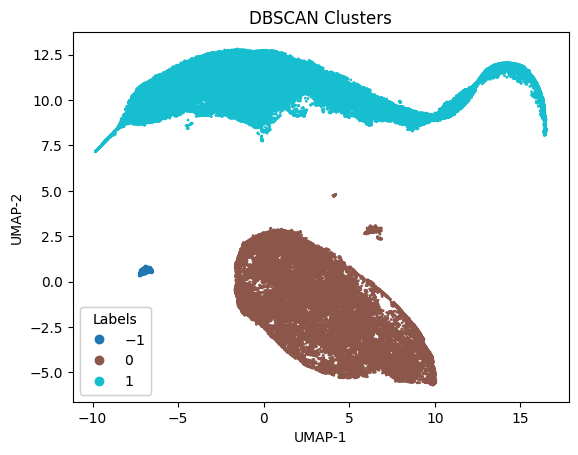

In [183]:
scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=labels,
    s=1,
    cmap='tab10'
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("DBSCAN Clusters")
# Create legend entries from the scatter plot
legend = plt.legend(
    *scatter.legend_elements(),
    title="Labels"
)

plt.gca().add_artist(legend)

plt.show()

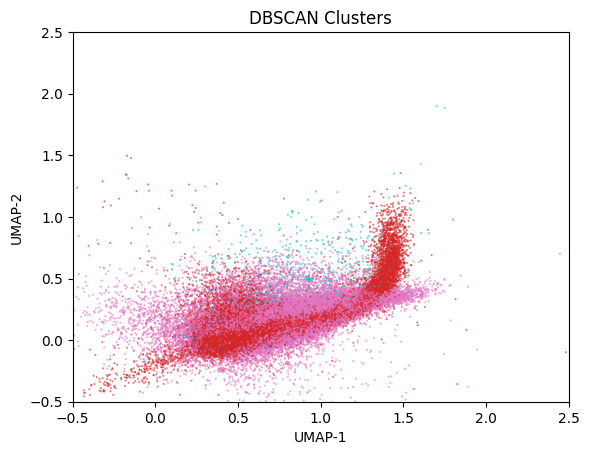

In [154]:
mask = labels != -1

scatter = plt.scatter(
    X[:,1][mask],
    X[:,2][mask],
    c=labels[mask],
    s=1,
    cmap='tab10',
    marker='o',
    linewidths=0.5,
    alpha=0.5,
    label='DBSCAN'
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("DBSCAN Clusters")
plt.xlim(-.5, 2.5)
plt.ylim(-.5, 2.5)
plt.show()

In [173]:
group_mask = labels == 3
group = X_subset[group_mask]
other = X_subset[~group_mask]
group_mean = group.mean(axis=0)
rest_mean = other.mean(axis=0)

global_std = X_subset.std(axis=0)

delta = (group_mean - rest_mean) / global_std

importance = pd.Series(
    delta,
    index=features
).sort_values(key=np.abs, ascending=False)

print(importance)

r_i      2.385370
VIS_Y    2.120972
u_g     -0.840284
g_r      0.598265
Y_J      0.551720
u_H      0.538067
J_H      0.262525
dtype: float64


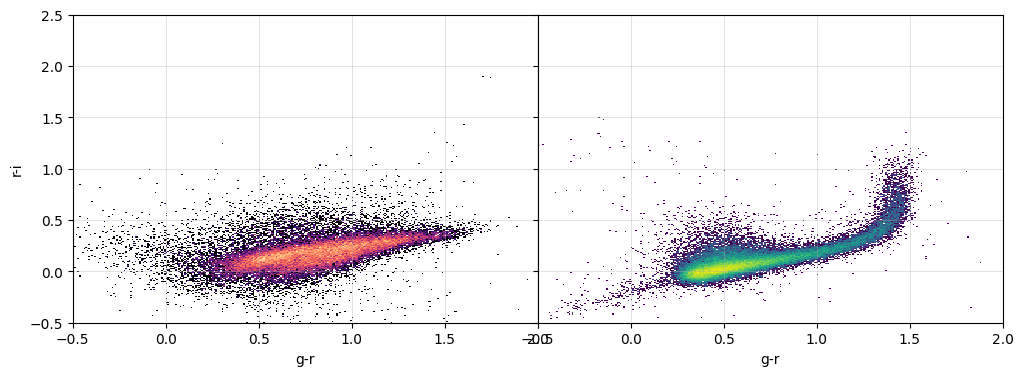

In [196]:
fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize=(12,4), gridspec_kw={'wspace': 0, 'hspace': 0})
xmin,xmax = -.5, 2
ymin,ymax = -.5, 2.5
n_bins= 300
x_bins = np.linspace(xmin, xmax, n_bins+1)
y_bins = np.linspace(ymin, ymax, n_bins+1)
bins = (x_bins, y_bins)
mask = (labels == 0)
color_x = 1
color_y = 2
H, xedges, yedges = np.histogram2d(
    X[:,color_x][mask], X[:,color_y][mask], bins=bins)
axes[0].pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='magma'
)
mask = ~mask & (labels != -1)
H, xedges, yedges = np.histogram2d(
    X[:,color_x][mask], X[:,color_y][mask], bins=bins)
axes[1].pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='viridis'
)

# plt.title("DBSCAN Clusters")
for ax in axes:
    ax.grid(True)
    ax.set_xlabel(features[color_x].replace('_', '-'))
# plt.xlim(-1.5, 2)
# plt.ylim(-1, 1)
axes[0].set_ylabel(features[color_y].replace('_', '-'))
plt.savefig('class_hist.png')
plt.show()

In [193]:
print(np.mean(df_total['point_source_probability_mer'][df_total['label'] == 0]))

0.018961195476095656


ValueError: too many values to unpack (expected 2)

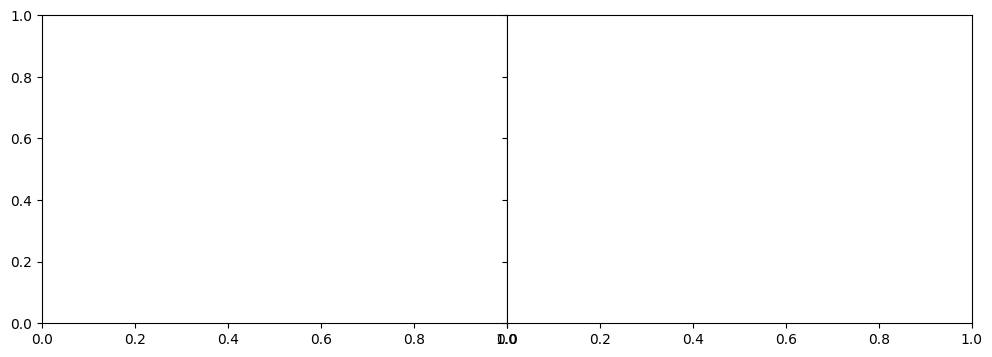

In [191]:
fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize=(12,4), gridspec_kw={'wspace': 0, 'hspace': 0})
xmin,xmax = -.5, 7.5
ymin,ymax = -.5, .5
n_bins= 300
x_bins = np.linspace(xmin, xmax, n_bins+1)
y_bins = np.linspace(ymin, ymax, n_bins+1)
bins = (x_bins, y_bins)
mask = (df_total['label'] == 1)
color_x = -2
color_y = -3
H, xedges, yedges = np.histogram2d(
    df_total[mask], df_total[mask], bins=bins)
axes[0].pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='magma'
)
mask = ~mask & (df_total['label'] != -1)
H, xedges, yedges = np.histogram2d(
    df_total[mask], df_total[mask], bins=bins)
axes[1].pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='viridis'
)

# plt.title("DBSCAN Clusters")
for ax in axes:
    ax.grid(True)
    ax.set_xlabel(features[color_x].replace('_', '-'))
# plt.xlim(-1.5, 2)
# plt.ylim(-1, 1)
axes[0].set_ylabel(features[color_y].replace('_', '-'))
plt.savefig('class_hist.png')
plt.show()

In [199]:
mask = pd.Series(True, index=df_total.index)

for b in bands:
    mask &= df_total[b] / df_total[f'{b}_sigma'] > 5
df_sel = df_total[mask].copy()
df_total.loc[df_sel.index, "label"] = labels

In [202]:
df_total[(df_total['label'] == 0) & (df_total['DES-G'] > 0)]

,id,tile_index,ra,dec,FWHM,point_source_probability_mer,weight_size,CFIS-U,CFIS-U_sigma,NIR-Y,...,VIS_sigma,DES-Z,DES-Z_sigma,DES-I,DES-I_sigma,DES-G,DES-G_sigma,DES-R,DES-R_sigma,label
112743,-636657677482500272,102021500,63.665768,-48.250027,1.267005,2.225737e-04,1.265,NaN,NaN,15064.128906,...,115.240070,9893.577264,1171.479756,8429.850155,594.077896,1954.723207,228.772162,4938.803235,418.537019,0
112955,-633007201482466162,102021500,63.300720,-48.246616,1.219279,5.552616e-04,1.215,NaN,NaN,8724.186820,...,88.492545,6142.184268,1092.551271,5603.788465,616.064522,1646.939733,246.893440,3435.231030,401.704643,0
112977,-637921653482469367,102021500,63.792165,-48.246937,1.266242,2.206540e-05,1.265,NaN,NaN,14239.060936,...,108.117717,9468.605550,1336.066610,6333.201495,611.861737,2112.779420,243.493080,3488.074549,473.872018,0
112978,-635640507482470031,102021500,63.564051,-48.247003,1.276534,9.952812e-07,1.275,NaN,NaN,19226.969849,...,156.321746,15497.463627,1174.437526,14056.690444,582.726310,6888.643659,228.807866,11637.883772,429.901089,0
112979,-635632815482475612,102021500,63.563282,-48.247561,1.276534,9.218168e-03,1.275,NaN,NaN,11848.843757,...,139.002174,7846.558045,1174.970760,6212.729665,582.757411,2950.168367,229.216616,4775.165735,404.203498,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29830131,-528861850260190366,102046760,52.886185,-26.019037,1.257319,0.000000e+00,1.255,NaN,NaN,38759.908749,...,157.544535,26618.565609,897.028822,20911.184505,776.556171,5217.892356,249.158494,13613.450278,314.015035,0
29830197,-528971181260171565,102046760,52.897118,-26.017157,1.241781,5.857782e-06,1.245,NaN,NaN,59176.347979,...,179.045484,40294.859129,1195.074767,32828.673575,1343.394305,4477.258441,258.278122,19707.859911,349.762498,0
29830198,-528962085260172464,102046760,52.896209,-26.017246,1.241781,2.513014e-03,1.245,NaN,NaN,11426.353414,...,129.698505,8178.022707,879.347804,5704.088110,663.500978,1278.272855,248.762212,3918.371059,231.854880,0
29830430,-528807525260096597,102046760,52.880753,-26.009660,1.260368,1.796300e-03,1.265,NaN,NaN,9675.808198,...,161.271763,6512.555626,847.129492,4973.348654,631.078508,1251.036265,237.583820,2656.030544,217.212889,0


In [203]:
pd.to_pickle(df_total, '../../all_fluxes_new.pkl')